# Análise de dimensionalidade: varredura de `min_df`

Pergunta: o modelo `word+char` tem mais features do que precisa? Aqui variamos o `min_df` dos dois `TfidfVectorizer` e medimos, para cada combinação, o número de features, o F1 de treino, o F1 da validação cruzada e o gap.

Para a comparação ser justa com os notebooks 02 e 03:
- mesmos dados (`dados_preparados.pkl`) e mesmos transformers (`transformers.pkl`), só trocando o `min_df` via `set_params`
- mesmos folds: `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`
- mesmos classificadores e hiperparâmetros (LR e LinearSVC)
- o teste (`X_te`) não é usado

In [1]:
# Resolve input and output paths from the supervised research root.
from pathlib import Path
import sys

_cwd = Path.cwd().resolve()
_candidates = [candidate for parent in (_cwd, *_cwd.parents)
               for candidate in (parent, parent / "machine-learning/supervised-learning")]
ROOT = next((candidate for candidate in _candidates
             if (candidate / "modelo_olimpo.py").is_file()
             and (candidate / "history/baselines/01_Data_Prep.ipynb").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Open this notebook from within the Olimpo repository.")
DATA = ROOT / "data"
HISTORY_RESULTS = ROOT / "history/resultados"
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Original experiment starts here.
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_validate

X_tr, X_te, y_tr, y_te = joblib.load((DATA / 'dados_preparados.pkl'))
configs = joblib.load((DATA / 'transformers.pkl'))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## Varredura

- `txt_word`: `min_df` ∈ {1, 2, 5, 10} (atual = 2)
- `txt_char`: `min_df` ∈ {1, 3, 5, 10} (atual = 3)

O número de features é a média dos 5 folds, lido do vocabulário que cada fold realmente aprendeu (`return_estimator=True`).

⚠️ Demora alguns minutos (32 validações cruzadas).

In [2]:
modelos = {
    "LR":  LogisticRegression(max_iter=1000, class_weight="balanced"),
    "SVC": LinearSVC(class_weight="balanced", random_state=42, max_iter=2000),
}
grade_word = [1, 2, 5, 10]
grade_char = [1, 3, 5, 10]

linhas = []
for nome, clf in modelos.items():
    for mw in grade_word:
        for mc in grade_char:
            pipe = Pipeline([("prep", ColumnTransformer(configs["word+char"])), ("clf", clone(clf))])
            pipe.set_params(prep__txt_word__min_df=mw, prep__txt_char__min_df=mc)
            r = cross_validate(pipe, X_tr, y_tr, cv=cv, scoring="f1_macro",
                               return_train_score=True, return_estimator=True, n_jobs=-1)
            n_word = np.mean([len(e.named_steps["prep"].named_transformers_["txt_word"].vocabulary_) for e in r["estimator"]])
            n_char = np.mean([len(e.named_steps["prep"].named_transformers_["txt_char"].vocabulary_) for e in r["estimator"]])
            linhas.append({
                "modelo": nome, "min_df_word": mw, "min_df_char": mc,
                "n_word": int(n_word), "n_char": int(n_char), "n_total": int(n_word + n_char),
                "f1_treino": r["train_score"].mean(),
                "f1_cv": r["test_score"].mean(), "f1_cv_std": r["test_score"].std(),
                "gap": r["train_score"].mean() - r["test_score"].mean(),
                "folds_cv": r["test_score"],
            })
            print(f"{nome} word={mw:>2} char={mc:>2} | feats={int(n_word + n_char):>7,} | "
                  f"treino={r['train_score'].mean():.4f} cv={r['test_score'].mean():.4f} ± {r['test_score'].std():.4f}")

res = pd.DataFrame(linhas)
res.drop(columns="folds_cv").to_csv((HISTORY_RESULTS / 'resultados_min_df.csv'), index=False)

LR word= 1 char= 1 | feats=344,416 | treino=0.9876 cv=0.9127 ± 0.0149


LR word= 1 char= 3 | feats=279,670 | treino=0.9862 cv=0.9144 ± 0.0130


LR word= 1 char= 5 | feats=265,043 | treino=0.9859 cv=0.9139 ± 0.0135


LR word= 1 char=10 | feats=251,039 | treino=0.9859 cv=0.9151 ± 0.0128


LR word= 2 char= 1 | feats=179,046 | treino=0.9849 cv=0.9168 ± 0.0131


...

SVC word= 5 char=10 | feats= 49,039 | treino=1.0000 cv=0.9272 ± 0.0056


SVC word=10 char= 1 | feats=133,414 | treino=1.0000 cv=0.9259 ± 0.0072


SVC word=10 char= 3 | feats= 68,668 | treino=1.0000 cv=0.9260 ± 0.0066


SVC word=10 char= 5 | feats= 54,041 | treino=1.0000 cv=0.9262 ± 0.0072


SVC word=10 char=10 | feats= 40,037 | treino=1.0000 cv=0.9259 ± 0.0056


## Tabelas

In [3]:
pd.set_option("display.width", 200)
for nome in modelos:
    print(f"\n=== {nome}: F1 da CV (linhas = min_df_word, colunas = min_df_char)")
    print(res[res.modelo == nome].pivot(index="min_df_word", columns="min_df_char", values="f1_cv").round(4))
    print(f"=== {nome}: gap treino - CV")
    print(res[res.modelo == nome].pivot(index="min_df_word", columns="min_df_char", values="gap").round(4))
print("\n=== Nº total de features (média dos folds)")
print(res[res.modelo == "LR"].pivot(index="min_df_word", columns="min_df_char", values="n_total"))


=== LR: F1 da CV (linhas = min_df_word, colunas = min_df_char)
min_df_char      1       3       5       10
min_df_word                                
1            0.9127  0.9144  0.9139  0.9151
2            0.9168  0.9182  0.9182  0.9172
5            0.9193  0.9191  0.9205  0.9196
10           0.9196  0.9193  0.9196  0.9189
=== LR: gap treino - CV
min_df_char      1       3       5       10
min_df_word                                
1            0.0749  0.0718  0.0721  0.0708
2            0.0681  0.0669  0.0662  0.0667
5            0.0635  0.0630  0.0611  0.0615
10           0.0609  0.0610  0.0601  0.0602

=== SVC: F1 da CV (linhas = min_df_word, colunas = min_df_char)
min_df_char      1       3       5       10
min_df_word                                
1            0.9290  0.9279  0.9279  0.9286
2            0.9292  0.9295  0.9293  0.9293
5            0.9279  0.9276  0.9276  0.9272
10           0.9259  0.9260  0.9262  0.9259
=== SVC: gap treino - CV
min_df_char      1       3    

## Comparação pareada com a configuração atual

Como todas as combinações usam os mesmos folds, dá para comparar fold a fold (diferença pareada). Isso tira a variação que vem de um fold ser mais fácil que outro, e o desvio padrão da diferença fica bem menor que o de cada modelo separado.

In [4]:
for nome in modelos:
    sub = res[res.modelo == nome]
    base = sub[(sub.min_df_word == 2) & (sub.min_df_char == 3)].iloc[0]
    d = sub.assign(
        delta_cv=[(f - base.folds_cv).mean() for f in sub.folds_cv],
        delta_std=[(f - base.folds_cv).std() for f in sub.folds_cv],
        folds_melhores=[int((f > base.folds_cv).sum()) for f in sub.folds_cv],
    )
    print(f"\n=== {nome} (base: word=2, char=3, F1 CV = {base.f1_cv:.4f}, {base.n_total:,} features)")
    print(d[["min_df_word", "min_df_char", "n_total", "f1_cv", "delta_cv", "delta_std", "folds_melhores", "gap"]]
          .sort_values("n_total").round(4).to_string(index=False))


=== LR (base: word=2, char=3, F1 CV = 0.9182, 114,301 features)
 min_df_word  min_df_char  n_total  f1_cv  delta_cv  delta_std  folds_melhores    gap
          10           10    40037 0.9189    0.0007     0.0039               3 0.0602
           5           10    49039 0.9196    0.0014     0.0032               4 0.0615
          10            5    54041 0.9196    0.0014     0.0029               4 0.0601
           5            5    63042 0.9205    0.0023     0.0031               4 0.0611
          10            3    68668 0.9193    0.0010     0.0027               3 0.0610
           5            3    77669 0.9191    0.0009     0.0025               2 0.0630
           2           10    85670 0.9172   -0.0010     0.0014               1 0.0667
           2            5    99673 0.9182   -0.0000     0.0008               2 0.0662
           2            3   114301 0.9182    0.0000     0.0000               0 0.0669
          10            1   133414 0.9196    0.0014     0.0031             

## Curva: F1 da CV × número de features

Cada linha é um `min_df_char`; os pontos ao longo da linha são os valores de `min_df_word` (menos features à esquerda = `min_df` maior). A estrela marca a configuração atual.

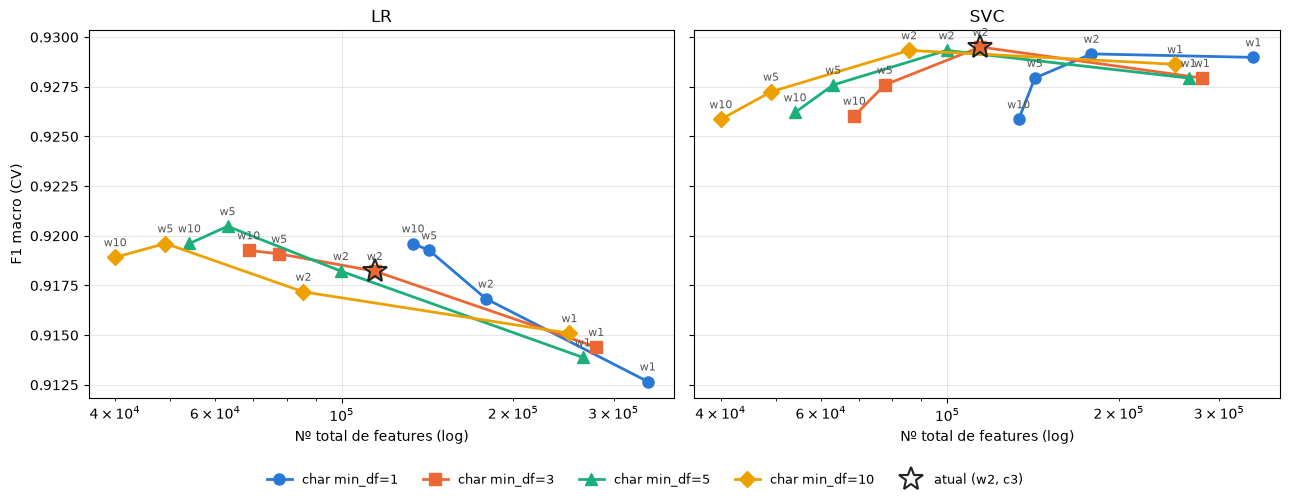

In [5]:
cores = {1: "#2a78d6", 3: "#eb6834", 5: "#1baf7a", 10: "#eda100"}
marcadores = {1: "o", 3: "s", 5: "^", 10: "D"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, nome in zip(axes, modelos):
    sub = res[res.modelo == nome]
    for mc in grade_char:
        s = sub[sub.min_df_char == mc].sort_values("n_total")
        ax.plot(s.n_total, s.f1_cv, color=cores[mc], marker=marcadores[mc], lw=2, ms=8,
                label=f"char min_df={mc}")
        for _, p in s.iterrows():
            ax.annotate(f"w{p.min_df_word}", (p.n_total, p.f1_cv), textcoords="offset points",
                        xytext=(0, 8), ha="center", fontsize=8, color="#555")
    base = sub[(sub.min_df_word == 2) & (sub.min_df_char == 3)].iloc[0]
    ax.plot(base.n_total, base.f1_cv, marker="*", ms=18, color="none", mec="#222", mew=1.5, label="atual (w2, c3)")
    ax.set_xscale("log")
    ax.set_title(nome)
    ax.set_xlabel("Nº total de features (log)")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("F1 macro (CV)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, fontsize=9, frameon=False)
plt.tight_layout(rect=(0, 0.07, 1, 1))
plt.show()

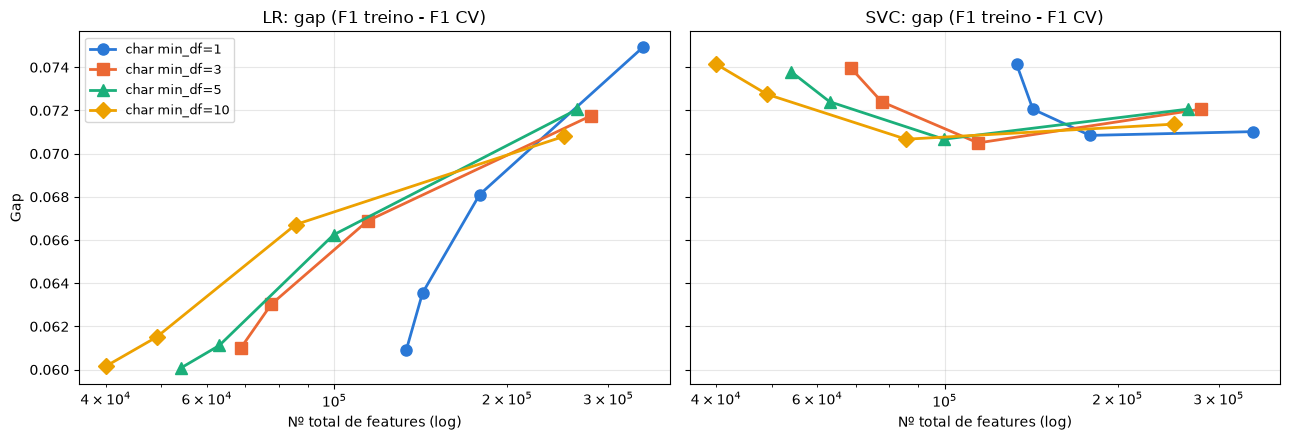

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, nome in zip(axes, modelos):
    sub = res[res.modelo == nome]
    for mc in grade_char:
        s = sub[sub.min_df_char == mc].sort_values("n_total")
        ax.plot(s.n_total, s.gap, color=cores[mc], marker=marcadores[mc], lw=2, ms=8, label=f"char min_df={mc}")
    ax.set_xscale("log")
    ax.set_title(f"{nome}: gap (F1 treino - F1 CV)")
    ax.set_xlabel("Nº total de features (log)")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("Gap")
axes[0].legend(fontsize=9)
plt.tight_layout()
plt.show()